In [55]:
from cProfile import label

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fontTools.designspaceLib import DesignSpaceDocumentError
from scipy.odr import quadratic
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RANSACRegressor, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('C:/Users/jesus/IA/machinelearning/machinelearningbook/archivos/curso4/house/housing.data',
                  header=None, sep='\\s+')

df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS',
              'NOX', 'RM', 'AGE', 'DIS', 'RAD',
              'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
df.shape

(506, 14)

In [4]:
#sns.set(style='whitegrid', context='notebook')
#cols = ['LSTAT', 'INDUS', 'NOX', 'RM', 'MEDV']

#sns.pairplot(df[cols], height=2.5)
#plt.tight_layout()
# plt.savefig('./figures/scatter.png', dpi=300)
#plt.show()

In [2]:
columns = ['Overall Qual', 'Overall Cond', 'Total Bsmt SF', 'Central Air', 'Gr Liv Area', 'SalePrice']
df2 = pd.read_csv('C:/Users/jesus/IA/machinelearning/machinelearningbook/archivos/curso4/house/AmesHousing.csv', usecols=columns)

In [3]:
df2.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [4]:
df2.shape

(2930, 6)

In [5]:
df2.columns

Index(['Overall Qual', 'Overall Cond', 'Total Bsmt SF', 'Central Air',
       'Gr Liv Area', 'SalePrice'],
      dtype='object')

In [6]:
df2['Central Air'] = df2['Central Air'].map({'N': 0, 'Y': 1})

In [7]:
df2.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,1,1656,215000
1,5,6,882.0,1,896,105000
2,6,6,1329.0,1,1329,172000
3,7,5,2110.0,1,2110,244000
4,5,5,928.0,1,1629,189900


In [8]:
df2.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [9]:
df2 = df2.dropna(axis=0)
df2.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [13]:
#scatterplotmatrix(df2.values, figsize=(12,10), names=df.columns, alpha=0.5)
#plt.tight_layout()
#plt.show()

In [ ]:
#cm = np.corrcoef(df2.values.T)
#hm = heatmap( cm, row_names=df.columns, col_names=df.columns )
#plt.tight_layout()
#plt.show()

In [10]:
class LinearRegressionGD_:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.array([0.])
        self.losses_ = []

        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors ** 2).mean()
            self.losses_.append(loss)
        return self


    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return self.net_input(X)


In [11]:
X = df2[['Gr Liv Area']].values
y = df2['SalePrice'].values
sc_x = StandardScaler()
sc_y = StandardScaler()

X_std = sc_x.fit_transform(X)
print(X_std)
y_std = sc_y.fit_transform(y[:, np.newaxis]).flatten()
lr = LinearRegressionGD_(eta=0.1)
lr.fit(X_std, y_std)


[[ 0.30887979]
 [-1.19492198]
 [-0.33815071]
 ...
 [-1.04849917]
 [-0.21942951]
 [ 0.98954796]]


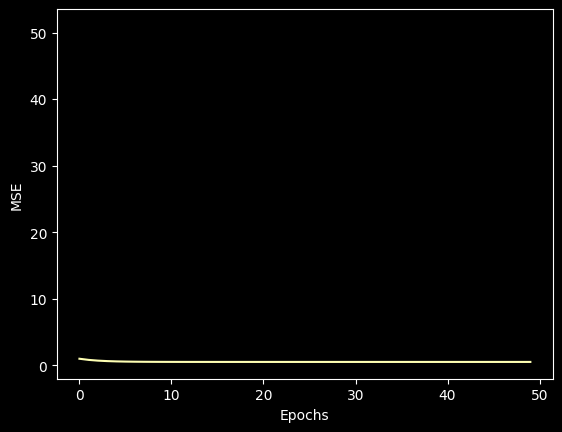

In [12]:
plt.plot(1, lr.n_iter + 1, lr.losses_)
plt.ylabel('MSE')
plt.xlabel('Epochs')
plt.show()

In [13]:
def lin_regplot(X, y, model):
    plt.scatter(X, y, c='steelblue', edgecolor='blue', s=70)
    plt.plot(X, model.predict(X), color='orange', lw=2)


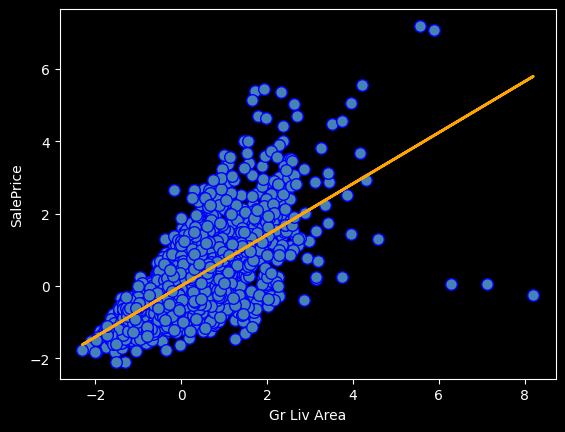

In [14]:
lin_regplot(X_std, y_std, lr)
plt.xlabel('Gr Liv Area')
plt.ylabel('SalePrice')

plt.show()

In [15]:
feature_std = sc_x.transform(np.array([[2500]]))
target_std = lr.predict(feature_std)
target_reverted = sc_y.inverse_transform(target_std.reshape(1, -1))


In [16]:
print(target_reverted.flatten()[0])

292507.0674366433


In [17]:
lr.w_[0]

np.float64(0.7066183690732503)

In [18]:
lr.b_[0]

np.float64(-1.585318121608827e-16)

In [19]:
slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)
print(f'slope: {slr.coef_[0]}, intercept: {slr.intercept_}')

slope: 111.66625842136432, intercept: 13342.97866235493


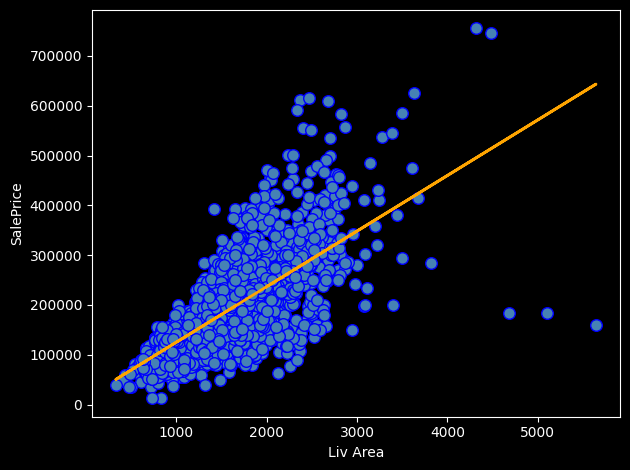

In [20]:
lin_regplot(X, y, slr)
plt.xlabel('Liv Area')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()

In [21]:
ransac = RANSACRegressor( LinearRegression(),  max_trials=100, min_samples=0.95,random_state=123 )
ransac.fit(X, y)

,"estimator estimator: object, default=NoneBase estimator object which implements the following methods:* `fit(X, y)`: Fit model to given training data and target values.* `score(X, y)`: Returns the mean accuracy on the given test data, which is used for the stop criterion defined by `stop_score`. Additionally, the score is used to decide which of two equally large consensus sets is chosen as the better one.* `predict(X)`: Returns predicted values using the linear model, which is used to compute residual error using loss function.If `estimator` is None, then:class:`~sklearn.linear_model.LinearRegression` is used fortarget values of dtype float.Note that the current implementation only supports regressionestimators.",LinearRegression()
,"min_samples min_samples: int (>= 1) or float ([0, 1]), default=NoneMinimum number of samples chosen randomly from original data. Treatedas an absolute number of samples for `min_samples >= 1`, treated as arelative number `ceil(min_samples * X.shape[0])` for`min_samples < 1`. This is typically chosen as the minimal number ofsamples necessary to estimate the given `estimator`. By default a:class:`~sklearn.linear_model.LinearRegression` estimator is assumed and`min_samples` is chosen as ``X.shape[1] + 1``. This parameter is highlydependent upon the model, so if a `estimator` other than:class:`~sklearn.linear_model.LinearRegression` is used, the user mustprovide a value.",0.95
,"residual_threshold residual_threshold: float, default=NoneMaximum residual for a data sample to be classified as an inlier.By default the threshold is chosen as the MAD (median absolutedeviation) of the target values `y`. Points whose residuals arestrictly equal to the threshold are considered as inliers.",None
,"is_data_valid is_data_valid: callable, default=NoneThis function is called with the randomly selected data before themodel is fitted to it: `is_data_valid(X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.",None
,"is_model_valid is_model_valid: callable, default=NoneThis function is called with the estimated model and the randomlyselected data: `is_model_valid(model, X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.Rejecting samples with this function is computationally costlier thanwith `is_data_valid`. `is_model_valid` should therefore only be used ifthe estimated model is needed for making the rejection decision.",None
,"max_trials max_trials: int, default=100Maximum number of iterations for random sample selection.",100
,"max_skips max_skips: int, default=np.infMaximum number of iterations that can be skipped due to finding zeroinliers or invalid data defined by ``is_data_valid`` or invalid modelsdefined by ``is_model_valid``... versionadded:: 0.19",inf
,"stop_n_inliers stop_n_inliers: int, default=np.infStop iteration if at least this number of inliers are found.",inf
,"stop_score stop_score: float, default=np.infStop iteration if score is greater equal than this threshold.",inf
,"stop_probability stop_probability: float in range [0, 1], default=0.99RANSAC iteration stops if at least one outlier-free set of the trainingdata is sampled in RANSAC. This requires to generate at least Nsamples (iterations):: N >= log(1 - probability) / log(1 - e**m)where the probability (confidence) is typically set to high value suchas 0.99 (the default) and e is the current fraction of inliers w.r.t.the total number of samples.",0.99
,"loss loss: str, callable, default='absolute_error'String inputs, 'absolute_error' and 'squared_error' are supported whichfind the absolute error and squared error per sample respectively.If ``loss`` is a callable, then it should be a function that takestwo arrays as inputs, the true and predicted value and returns a 1-Darray with the i-th value of the array corresponding to the losson ``X[i]``.If the loss on a sample is greater than the ``residual_threshold``,then this sample is classified as an outlier... versionadded:: 0.18"

In [22]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)
line_X = np.arange(3,10,1)
line_y_ransac = ransac.predict(line_X[:, np.newaxis])


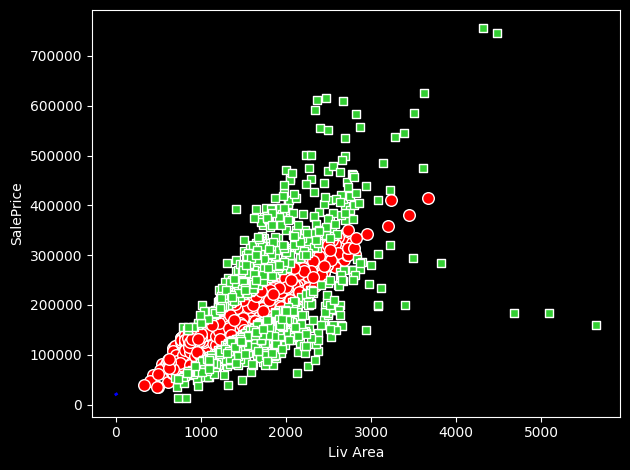

In [23]:
plt.scatter( X[inlier_mask], y[inlier_mask], c='red', edgecolor='white', s=70, marker='o', label='Inliers' )
plt.scatter(X[outlier_mask], y[outlier_mask], c='limegreen', edgecolor='white', marker='s', label='Outliers' )
plt.plot(line_X, line_y_ransac, color='blue', lw=2)
plt.xlabel('Liv Area')
plt.ylabel('SalePrice')
plt.tight_layout()


In [24]:
print(f'Slope: {ransac.estimator_.coef_[0]}, Intercept: {ransac.estimator_.intercept_}')

Slope: 106.34799703561391, Intercept: 20190.092616849084


In [25]:
def mean_absolute_deviation(data):
    return np.mean(np.abs(data - np.median(data)))

In [26]:
target = 'SalePrice'

X = df2[['Overall Qual', 'Overall Cond', 'Total Bsmt SF', 'Central Air',
       'Gr Liv Area']].values
y = df2[target].values

In [27]:
print(X.shape)

(2929, 5)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
slr = LinearRegression()
slr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)

In [30]:
x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

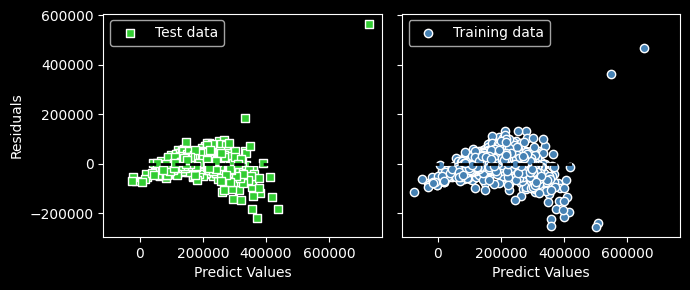

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(y_test_pred, y_test_pred - y_test, c='limegreen', marker='s', edgecolor='white', label='Test data')
ax2.scatter(y_train_pred, y_train_pred - y_train, c='steelblue', marker='o', edgecolor='white', label='Training data')
ax1.set_ylabel('Residuals')

for ax in (ax1, ax2):
    ax.set_xlabel('Predict Values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100, color='black', linestyle='--', lw=2)

plt.tight_layout()
plt.show()

In [32]:
mae_train = mean_squared_error(y_train, y_train_pred)
mae_test = mean_squared_error(y_test, y_test_pred)
print(f'MAE train: {mae_train}, MAE test: {mae_test}')

MAE train: 1497216245.853398, MAE test: 1516565820.9990351


In [33]:
re_train = r2_score(y_train, y_train_pred)
re_test = r2_score(y_test, y_test_pred)
print(f'R2 train: {re_train}, R2 test: {re_test}')

R2 train: 0.7694948430504934, R2 test: 0.7515748205718921


In [34]:
mse_train = mean_absolute_error(y_train, y_train_pred)
mse_test = mean_absolute_error(y_test, y_test_pred)
print(f'MSE train: {mse_train}, MSE test: {mse_test}')

MSE train: 25983.026623990812, MSE test: 24921.288963945477


In [35]:
ridge = Ridge(alpha=1.0)

In [36]:
lasso = Lasso(alpha=1.0)

In [37]:
elanet = ElasticNet(alpha=1.0, l1_ratio=0.5)

In [38]:
X = np.array([258.0, 270.0, 294.0,
              320.0, 342.0, 368.0,
              396.0, 446.0, 480.0, 586.0])[:, np.newaxis]

y = np.array([236.4, 234.4, 252.8,
              298.6, 314.2, 342.2,
              360.8, 368.0, 391.2,
              390.8])

In [39]:
lr = LinearRegression()
pr = LinearRegression()
quadratic = PolynomialFeatures(degree=2)
X_quad = quadratic.fit_transform(X)

In [40]:
lr.fit(X, y)
X_fit = np.arange(250, 600, 10)[:, np.newaxis]
y_lin_fit = lr.predict(X_fit)

In [41]:
pr.fit(X_quad, y)
y_quad_fit = pr.predict(quadratic.fit_transform(X_fit))

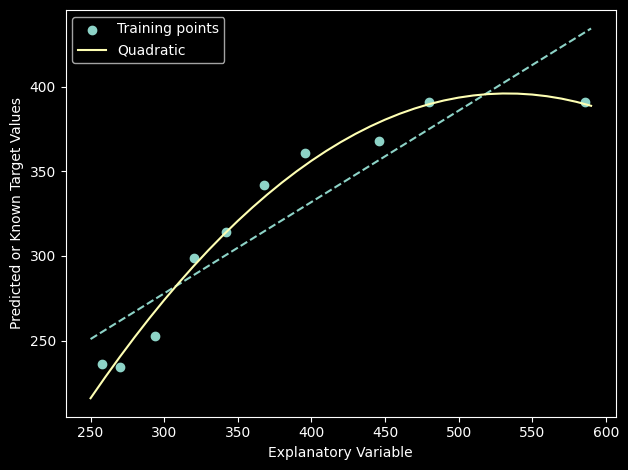

In [42]:
plt.scatter(X, y, label='Training points')
plt.plot(X_fit, y_lin_fit, linestyle='--')
plt.plot(X_fit, y_quad_fit, label='Quadratic')
plt.xlabel('Explanatory Variable')
plt.ylabel('Predicted or Known Target Values')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [43]:
y_lin_pred = lr.predict(X)
y_quad_pred = pr.predict(X_quad)
mse_lin = mean_squared_error(y, y_lin_pred)
mse_quad = mean_squared_error(y, y_quad_pred)
print(f'Training MSE Linear: {mse_lin}, Testing MSE quadratic: {mse_quad}')

Training MSE Linear: 569.7796663183207, Testing MSE quadratic: 61.33021451744772


In [44]:
r2_lin = r2_score(y, y_lin_pred)
r2_quad = r2_score(y, y_quad_pred)
print(f'Trainin R2 linear: {r2_lin}, Testin R2 quadratic: {r2_quad}')

Trainin R2 linear: 0.8317053837891232, Testin R2 quadratic: 0.9818850241163604


In [45]:
X = df2[['Gr Liv Area']].values
y = df2['SalePrice'].values


In [46]:
print(X)

[[1656]
 [ 896]
 [1329]
 ...
 [ 970]
 [1389]
 [2000]]


In [47]:
quadratic = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)
X_quad = quadratic.fit_transform(X)
X_cubic = cubic.fit_transform(X)

In [48]:
y.shape

(2929,)

In [49]:
X.shape

(2929, 1)

In [50]:
df2[['Gr Liv Area']].shape

(2929, 1)

In [51]:
regr = LinearRegression()
X_fit = np.arange(X.min()-1, X.max()+2, 1)[:, np.newaxis]
regr = regr.fit(X,y)

In [52]:
y_lin_fit = regr.predict(X_fit)
linear_r2 = r2_score(y, regr.predict(X))
regr = regr.fit(X_quad, y)
y_quad_fit = regr.predict(quadratic.fit_transform(X_fit))

In [53]:
quadratic_r2 = r2_score(y, regr.predict(X_quad))
regr = regr.fit(X_cubic, y)
y_cubic_fit = regr.predict(cubic.fit_transform(X_fit))
cubic_r2 =  r2_score(y, regr.predict(X_cubic))

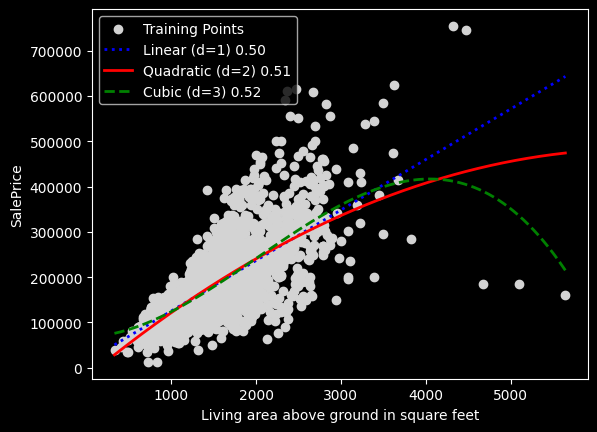

In [54]:
plt.scatter(X, y, label='Training Points', color='lightgray')
plt.plot(X_fit, y_lin_fit, label=f'Linear (d=1) {linear_r2:.2f}', lw=2, color='blue', linestyle=':')
plt.plot(X_fit, y_quad_fit, label=f'Quadratic (d=2) {quadratic_r2:.2f}', lw=2, color='red', linestyle='-')
plt.plot(X_fit, y_cubic_fit, label=f'Cubic (d=3) {cubic_r2:.2f}', lw=2, color='green', linestyle='--')
plt.xlabel('Living area above ground in square feet')
plt.ylabel('SalePrice')
plt.legend(loc='upper left')
plt.show()

In [58]:
X = df2[['Gr Liv Area']].values
y = df2['SalePrice'].values
tree = DecisionTreeClassifier(max_depth=3)

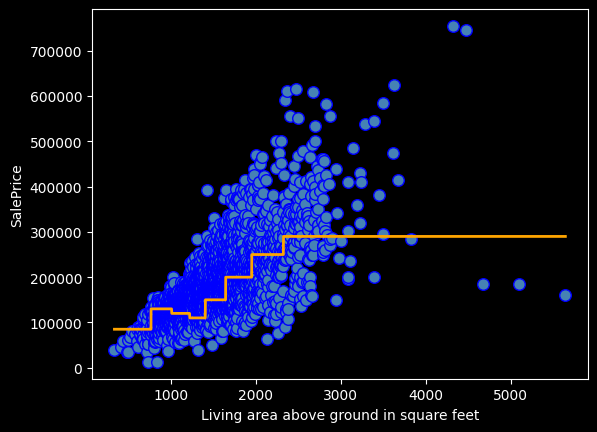

In [59]:
tree.fit(X,y)
sort_idx = X.flatten().argsort()
lin_regplot(X[sort_idx], y[sort_idx], tree)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('SalePrice')
plt.show()

In [60]:
target = 'SalePrice'
X = df2[['Overall Qual', 'Overall Cond', 'Total Bsmt SF', 'Central Air',
       'Gr Liv Area']].values
y = df2[target].values

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
forest = RandomForestClassifier(n_estimators=1000, criterion='gini', random_state=1, n_jobs=-1)
forest.fit(X_train, y_train)
y_train_pred = forest.predict(X_train)
y_test_pred = forest.predict(X_test)

In [66]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f'MAE Train: {mae_train}, MAE Test: {mae_test}')

MAE Train: 900.1643902439024, MAE Test: 26313.9795221843


In [67]:
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f'R2 Train: {r2_train}, R2 Test: {r2_test}')

R2 Train: 0.9958148114089539, R2 Test: 0.7681110342849772


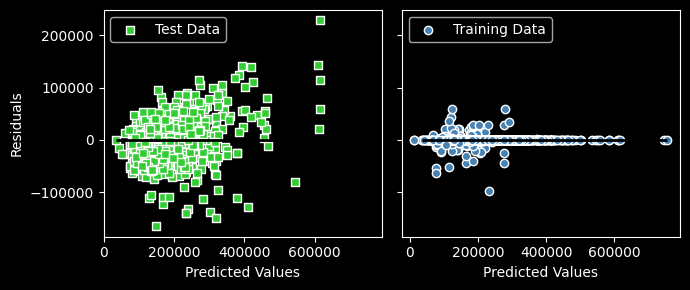

In [69]:
x_max = np.max( [np.max(y_train_pred), np.max(y_test_pred)] )
x_min = np.max( [np.min(y_train_pred), np.min(y_test_pred)] )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

ax1.scatter(y_test_pred, y_test_pred - y_test, c='limegreen',  marker='s', edgecolors='white', label='Test Data')
ax2.scatter(y_train_pred, y_train_pred - y_train, c='steelblue',  marker='o', edgecolors='white', label='Training Data')
ax1.set_ylabel('Residuals')

for ax in (ax1, ax2):
    ax.set(xlabel='Predicted Values')
    ax.legend(loc='upper left')
    ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100, lw=2, color='black')

plt.tight_layout()
plt.show()
